# Israeli Actors Graph — Link Prediction (Step 5)

Builds and evaluates a temporal link-prediction model on the Israeli actors
co-appearance graph (Assignment Step 5).

## Temporal design

| | X (features) | y (labels) | years_ahead |
|---|---|---|---|
| **Train** | G_1990_2015: 1990–2015 | New links 2016–2020 | 5 |
| **Test**  | G_1990_2020:   1990–2020 | New links 2021–2025 | 5 |
| **Future predictions** | G_1990_2025: 1990–2025 | — | user-specified |

The `years_ahead` feature tells the model *how far into the future* it is
predicting.  Both train and test use 5 years here, but varying it at inference
time (e.g. 1, 2, 3, 5) lets you score short-term vs long-term predictions with
a single trained model.

## Features (24 total with years_ahead)

* **Topological (5)**: Common Neighbors, Jaccard, Adamic-Adar, Preferential Attachment, shortest-path distance
* **Centrality (16)**: degree / betweenness / closeness / eigenvector × {u, v, product, abs-diff}
* **SVD (2)**: cosine similarity + dot product of adjacency-SVD embeddings
* **years_ahead (1)**: prediction horizon in years

## Models compared
Logistic Regression and Random Forest; evaluated on the 2021–2025 temporal test set.


In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sys.path.insert(0, os.path.abspath('../src'))
sys.path.insert(0, os.path.abspath('../..'))

import graph_build
import link_features as lf
import link_prediction as lp_mod

warnings.filterwarnings('ignore')
if sys.stdout.encoding and sys.stdout.encoding.lower() != 'utf-8':
    sys.stdout.reconfigure(encoding='utf-8')

plt.rcParams['font.family'] = 'Arial'
SEED = 42
os.makedirs('../figures', exist_ok=True)
print('Imports OK')

Imports OK


## 1. Data and temporal split

cast_edges: 2,972 rows | 759 unique films
Year range: 1933 – 2026

Temporal split (X = features, y = labels):
  Train  X: G_1990_2015 1990–2015  |  y: new links 2016–2020  |  years_ahead=5
  Test   X: G_1990_2020   1990–2020  |  y: new links 2021–2025  |  years_ahead=5
  Future X: G_1990_2025  1990–2025  |  y: unknown (2026+)       |  user-specified


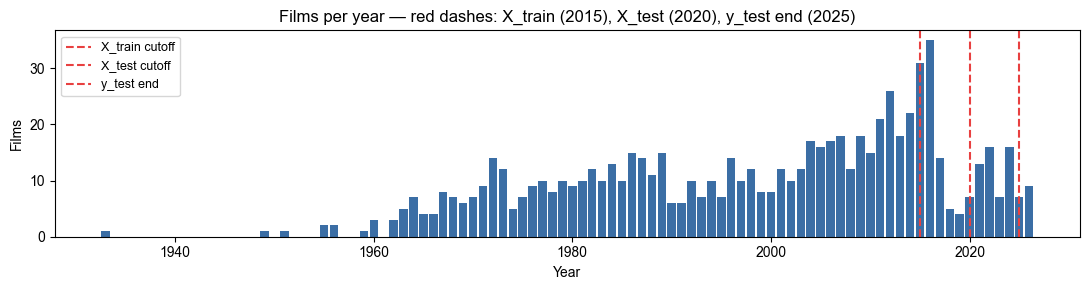

In [2]:
cast_edges = graph_build.load_cast_edges('../data/processed/cast_edges.csv')
year_min_data = int(cast_edges['year'].min())
year_max_data = int(cast_edges['year'].max())

n_films = cast_edges['movie_slug'].nunique()
print(f'cast_edges: {len(cast_edges):,} rows | {n_films:,} unique films')
print(f'Year range: {year_min_data} – {year_max_data}')
print()
print('Temporal split (X = features, y = labels):')
print('  Train  X: G_1990_2015 1990–2015  |  y: new links 2016–2020  |  years_ahead=5')
print('  Test   X: G_1990_2020   1990–2020  |  y: new links 2021–2025  |  years_ahead=5')
print('  Future X: G_1990_2025  1990–2025  |  y: unknown (2026+)       |  user-specified')

# Films per year bar chart
films_per_year = cast_edges.groupby('year')['movie_slug'].nunique()
fig, ax = plt.subplots(figsize=(11, 3))
ax.bar(films_per_year.index, films_per_year.values, color='#3b6ea5', width=0.85)
for cutoff, label in [(2015, 'X_train cutoff'), (2020, 'X_test cutoff'), (2025, 'y_test end')]:
    ax.axvline(cutoff, color='#e84040', linestyle='--', linewidth=1.5, label=label)
ax.set_xlabel('Year'); ax.set_ylabel('Films')
ax.set_title('Films per year — red dashes: X_train (2015), X_test (2020), y_test end (2025)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../figures/films_per_year_cutoffs.png', dpi=150, bbox_inches='tight')
plt.show()


In [3]:
YEARS_AHEAD = 5   # prediction horizon — both train and test predict 5 years ahead

print('Building G_1990_2015 (1990–2015, X_train feature graph)...')
G_1990_2015 = lp_mod.build_graph_for_years(cast_edges, 1990, 2015)
n_early, m_early = G_1990_2015.number_of_nodes(), G_1990_2015.number_of_edges()
print(f'  {n_early} actors, {m_early} unique collaborations')

print('Building G_1990_2020   (1990–2020, X_test feature graph + y_train source)...')
G_1990_2020 = lp_mod.build_graph_for_years(cast_edges, 1990, 2020)
n_mid, m_mid = G_1990_2020.number_of_nodes(), G_1990_2020.number_of_edges()
print(f'  {n_mid} actors, {m_mid} unique collaborations')

print('Building G_1990_2025  (1990–2025, y_test source + future candidates)...')
G_1990_2025 = lp_mod.build_graph_for_years(cast_edges, 1990, 2025)
n_eval, m_eval = G_1990_2025.number_of_nodes(), G_1990_2025.number_of_edges()
print(f'  {n_eval} actors, {m_eval} unique collaborations')

print()
print(f'y_train (2016–2020): +{n_mid - n_early} actors, +{m_mid - m_early} new collaborations')
print(f'y_test  (2021–2025): +{n_eval - n_mid}  actors, +{m_eval - m_mid}  new collaborations')


Building G_1990_2015 (1990–2015, X_train feature graph)...
  691 actors, 1907 unique collaborations
Building G_1990_2020   (1990–2020, X_test feature graph + y_train source)...
  837 actors, 2653 unique collaborations
Building G_1990_2025  (1990–2025, y_test source + future candidates)...
  1080 actors, 4601 unique collaborations

y_train (2016–2020): +146 actors, +746 new collaborations
y_test  (2021–2025): +243  actors, +1948  new collaborations


## 2. Positive and negative pairs

**Training positives** (y_train = 1): pairs that formed a new link in 2016–2020,
both actors existing in G_1990_2015. Features (X_train) are from G_1990_2015 — no future leak.

**Test positives** (y_test = 1): pairs that formed a new link in 2021–2025,
both actors existing in G_1990_2020. Features (X_test) are from G_1990_2020 — no future leak.

**Negatives**: sampled non-edges from the respective feature graph, excluded if
they ever form a connection during the label window.


In [4]:
# TRAINING positives: new links 2016–2020 (y_train = 1)
pos_train = lp_mod.get_new_pairs(G_1990_2015, G_1990_2020)
print(f'Training positives (new links 2016–2020): {len(pos_train)}')

# TEST positives: new links 2021–2025 (y_test = 1)
pos_test = lp_mod.get_new_pairs(G_1990_2020, G_1990_2025)
print(f'Test positives    (new links 2021–2025): {len(pos_test)}')

# Leakage guards
assert all(not G_1990_2015.has_edge(u, v) for u, v in pos_train), 'Train leakage!'
assert all(not G_1990_2020.has_edge(u, v)   for u, v in pos_test),  'Test leakage!'
print('Leakage checks PASSED.')


Training positives (new links 2016–2020): 191
Test positives    (new links 2021–2025): 282
Leakage checks PASSED.


Train: 477 samples  (191 pos / 286 neg)
Test : 705  samples  (282 pos / 423 neg)


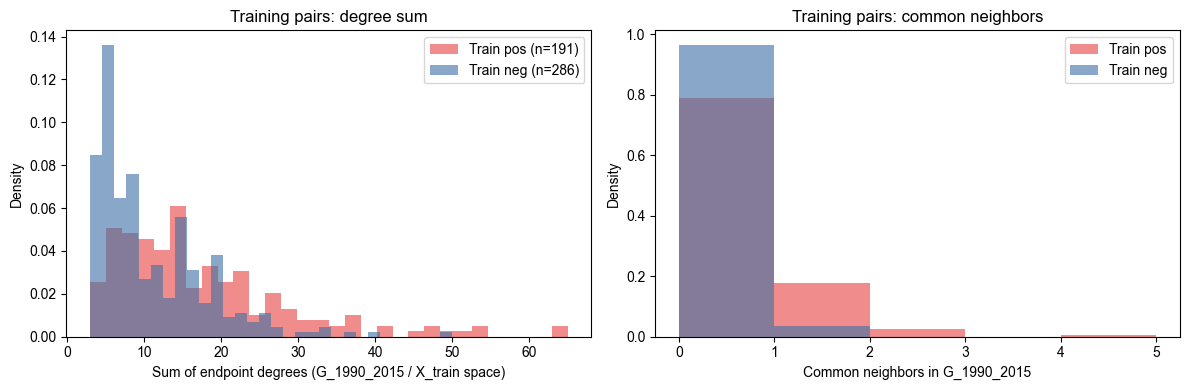

In [5]:
# TRAINING negatives: sampled from G_1990_2015, exclude pairs that DO form in G_1990_2020
pos_set_mid  = {(min(u,v),max(u,v)) for u,v in G_1990_2020.edges()}
neg_train    = lp_mod.sample_negatives(
    G_1990_2015, int(len(pos_train) * lp_mod.NEG_RATIO),
    exclude_pairs=pos_set_mid, seed=SEED)

# TEST negatives: sampled from G_1990_2020, exclude pairs that DO form in G_1990_2025
pos_set_eval = {(min(u,v),max(u,v)) for u,v in G_1990_2025.edges()}
neg_test     = lp_mod.sample_negatives(
    G_1990_2020, int(len(pos_test) * lp_mod.NEG_RATIO),
    exclude_pairs=pos_set_eval, seed=SEED)

# Compile full arrays
all_train_pairs = [(min(u,v),max(u,v)) for u,v in pos_train] + neg_train
all_test_pairs  = [(min(u,v),max(u,v)) for u,v in pos_test]  + neg_test
y_train = np.array([1]*len(pos_train) + [0]*len(neg_train))
y_test  = np.array([1]*len(pos_test)  + [0]*len(neg_test))

print(f'Train: {len(y_train)} samples  ({y_train.sum()} pos / {(y_train==0).sum()} neg)')
print(f'Test : {len(y_test)}  samples  ({y_test.sum()} pos / {(y_test==0).sum()} neg)')

# Degree-sum and CN distributions for training pairs (X_train space)
pos_deg_sum = [G_1990_2015.degree(u) + G_1990_2015.degree(v) for u,v in pos_train]
neg_deg_sum = [G_1990_2015.degree(u) + G_1990_2015.degree(v) for u,v in neg_train]
pos_cn = [len(list(nx.common_neighbors(G_1990_2015, u, v))) for u,v in pos_train]
neg_cn = [len(list(nx.common_neighbors(G_1990_2015, u, v))) for u,v in neg_train]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pos_deg_sum, bins=30, alpha=0.6, density=True,
             color='#e84040', label=f'Train pos (n={len(pos_train)})')
axes[0].hist(neg_deg_sum, bins=30, alpha=0.6, density=True,
             color='#3b6ea5', label=f'Train neg (n={len(neg_train)})')
axes[0].set_xlabel('Sum of endpoint degrees (G_1990_2015 / X_train space)')
axes[0].set_ylabel('Density')
axes[0].set_title('Training pairs: degree sum')
axes[0].legend()

max_cn = max(max(pos_cn, default=0), max(neg_cn, default=0))
axes[1].hist(pos_cn, bins=range(0, max_cn+2), alpha=0.6, density=True,
             color='#e84040', label='Train pos')
axes[1].hist(neg_cn, bins=range(0, max_cn+2), alpha=0.6, density=True,
             color='#3b6ea5', label='Train neg')
axes[1].set_xlabel('Common neighbors in G_1990_2015')
axes[1].set_ylabel('Density')
axes[1].set_title('Training pairs: common neighbors')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/pair_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Training feature computation (X_train from G_1990_2015 + years_ahead=5)

All training features are computed **strictly from G_1990_2015 (1990–2015)** — no
information from the 2016–2020 label window leaks in.

The `years_ahead=5` feature is appended to every training sample: the model
learns that these predictions target a 5-year horizon.


In [6]:
print('Computing centralities on G_1990_2015 (X_train)...')
cents_1990_2015 = lp_mod.compute_centralities(G_1990_2015)
print('  Done.')

print('Computing topological features for training pairs...')
topo_df = lf.topological_features(G_1990_2015, all_train_pairs)
print('Training topological features (positive + negative combined):')
topo_df[['common_neighbors', 'jaccard', 'adamic_adar',
         'pref_attachment', 'shortest_path']].describe().round(3)


Computing centralities on G_1990_2015 (X_train)...
  Done.
Computing topological features for training pairs...
Training topological features (positive + negative combined):


,common_neighbors,jaccard,adamic_adar,pref_attachment,shortest_path
count,477.000,477.000,477.000,477.000,477.000
mean,0.122,0.006,0.040,49.421,2.897
std,0.391,0.022,0.130,86.470,2.332
min,0.000,0.000,0.000,0.000,-1.000
25%,0.000,0.000,0.000,9.000,2.000
50%,0.000,0.000,0.000,24.000,3.000
75%,0.000,0.000,0.000,52.000,4.000
max,4.000,0.167,1.345,816.000,9.000


In [7]:
print('Computing SVD node embeddings on G_1990_2015 (n_components=32)...')
svd_1990_2015  = lf.svd_node_embeddings(G_1990_2015, n_components=32, seed=SEED)
svd_feat_train = lf.cosine_similarity_feature(all_train_pairs, svd_1990_2015, prefix='svd_')
print('SVD cosine-similarity (training pairs):')
print(svd_feat_train.describe().round(3))

pos_svd = svd_feat_train.loc[:len(pos_train)-1, 'svd_cosine_sim'].mean()
neg_svd = svd_feat_train.loc[len(pos_train):,   'svd_cosine_sim'].mean()
print(f'\nMean SVD cosine sim — positive: {pos_svd:.3f} | negative: {neg_svd:.3f}')


Computing SVD node embeddings on G_1990_2015 (n_components=32)...
SVD cosine-similarity (training pairs):
       svd_cosine_sim  svd_dot_product
count         477.000          477.000
mean            0.033            0.150
std             0.171            0.550
min            -0.725           -0.704
25%            -0.042           -0.019
50%             0.000            0.000
75%             0.076            0.052
max             0.781            7.499

Mean SVD cosine sim — positive: 0.062 | negative: 0.013


In [8]:
# Initialise BEFORE the try-block so subsequent cells never see NameError
HAS_N2V       = False
n2v_1990_2015 = None

print('Computing Node2Vec embeddings on G_1990_2015 (may take 30–90 seconds)...')

try:
    n2v_1990_2015 = lf.node2vec_node_embeddings(
        G_1990_2015, dimensions=64, walk_length=20, num_walks=50, seed=SEED)
    n2v_feat_train = lf.cosine_similarity_feature(
        all_train_pairs, n2v_1990_2015, prefix='n2v_')
    HAS_N2V = True
    pos_n2v = n2v_feat_train.loc[:len(pos_train)-1, 'n2v_cosine_sim'].mean()
    neg_n2v = n2v_feat_train.loc[len(pos_train):,   'n2v_cosine_sim'].mean()
    print(f'Node2Vec done. Mean cosine sim — pos: {pos_n2v:.3f} | neg: {neg_n2v:.3f}')
except Exception as exc:
    print(f'Node2Vec unavailable ({exc}). Proceeding without it.')


Computing Node2Vec embeddings on G_1990_2015 (may take 30–90 seconds)...
Node2Vec done. Mean cosine sim — pos: 0.301 | neg: 0.294


In [9]:
# Full training feature matrix (with N2V if available, years_ahead=5)
X, feat_names = lf.build_feature_matrix(
    G_1990_2015, all_train_pairs, cents_1990_2015,
    svd_emb=svd_1990_2015,
    n2v_emb=n2v_1990_2015 if HAS_N2V else None,
    years_ahead=YEARS_AHEAD)

print(f'Training feature matrix (X): {X.shape[0]} samples  x  {X.shape[1]} features')
print(f'  {y_train.sum()} positive / {(y_train==0).sum()} negative')
print()
print('Features included:')
print(f'  Topological  (5)  : CN, Jaccard, Adamic-Adar, Pref.Attachment, ShortestPath')
print(f'  Centrality   (16) : degree/betweenness/closeness/eigenvector x {{u,v,prod,diff}}')
print(f'  SVD          (2)  : cosine_sim, dot_product')
if HAS_N2V:
    print(f'  Node2Vec     (2)  : cosine_sim, dot_product')
print(f'  years_ahead  (1)  : {YEARS_AHEAD} (5-year prediction horizon)')
print(f'\nNaN values: {int(np.isnan(X).sum())} (should be 0)')


Training feature matrix (X): 477 samples  x  26 features
  191 positive / 286 negative

Features included:
  Topological  (5)  : CN, Jaccard, Adamic-Adar, Pref.Attachment, ShortestPath
  Centrality   (16) : degree/betweenness/closeness/eigenvector x {u,v,prod,diff}
  SVD          (2)  : cosine_sim, dot_product
  Node2Vec     (2)  : cosine_sim, dot_product
  years_ahead  (1)  : 5 (5-year prediction horizon)

NaN values: 0 (should be 0)


## 4. Model training

**X_train**: G_1990_2015 (1990–2015) features + years_ahead=5  
**y_train**: 1 = new link formed 2016–2020, 0 = remained non-edge through 2020


In [10]:
# N2V-free X_train (consistent with X_test from G_1990_2020, which also skips N2V)
X_train, feat_names_train = lf.build_feature_matrix(
    G_1990_2015, all_train_pairs, cents_1990_2015,
    svd_emb=svd_1990_2015, n2v_emb=None,
    years_ahead=YEARS_AHEAD)

print(f'X_train: {X_train.shape}  (y_train: {y_train.sum()} pos / {(y_train==0).sum()} neg)')
print(f'Feature count: {X_train.shape[1]}  (includes years_ahead={YEARS_AHEAD})')
print()
print('Training Logistic Regression...')
lr_model, lr_scaler = lp_mod.train_logistic_regression(X_train, y_train, seed=SEED)
print('Training Random Forest...')
rf_model = lp_mod.train_random_forest(X_train, y_train, seed=SEED)
print('Both models trained.')


X_train: (477, 24)  (y_train: 191 pos / 286 neg)
Feature count: 24  (includes years_ahead=5)

Training Logistic Regression...
Training Random Forest...
Both models trained.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# MODEL PARAMETERS & TRAINING PERFORMANCE
# ═══════════════════════════════════════════════════════════════════════════

print('═' * 75)
print('  MODEL CONFIGURATION & TRAINING METRICS')
print('═' * 75)
print()

# ─────────────────────────────────────────────────────────────────────────
# Logistic Regression
# ─────────────────────────────────────────────────────────────────────────
print('Logistic Regression:')
print(f'  ├─ Solver: {lr_model.solver}')
print(f'  ├─ Max iterations: {lr_model.max_iter}')
print(f'  ├─ Actual iterations: {lr_model.n_iter_[0]}')
print(f'  ├─ C (regularization): {lr_model.C} (higher = less regularization)')
print(f'  ├─ Class weight: {lr_model.class_weight}')
print(f'  └─ Converged: {"✓ YES" if lr_model.n_iter_[0] < lr_model.max_iter else "✗ NO (reached max_iter)"}')

# Train accuracy
X_train_scaled = lr_scaler.transform(X_train)
lr_train_acc = lr_model.score(X_train_scaled, y_train)
lr_train_proba = lr_model.predict_proba(X_train_scaled)[:, 1]
lr_train_auc = lp_mod.roc_auc_score(y_train, lr_train_proba)

print()
print('  Training Performance:')
print(f'    ├─ Train Accuracy:  {lr_train_acc:.3f}')
print(f'    └─ Train AUC-ROC:   {lr_train_auc:.3f}')

print()
print('─' * 75)
print()

# ─────────────────────────────────────────────────────────────────────────
# Random Forest
# ─────────────────────────────────────────────────────────────────────────
print('Random Forest:')
print(f'  ├─ Number of trees (n_estimators): {rf_model.n_estimators}')
print(f'  ├─ Max depth: {rf_model.max_depth}')
print(f'  ├─ Min samples per leaf: {rf_model.min_samples_leaf}')
print(f'  ├─ Class weight: {rf_model.class_weight}')
print(f'  └─ Number of features used: {rf_model.n_features_in_}')

# Train accuracy
rf_train_acc = rf_model.score(X_train, y_train)
rf_train_proba = rf_model.predict_proba(X_train)[:, 1]
rf_train_auc = lp_mod.roc_auc_score(y_train, rf_train_proba)

print()
print('  Training Performance:')
print(f'    ├─ Train Accuracy:  {rf_train_acc:.3f}')
print(f'    └─ Train AUC-ROC:   {rf_train_auc:.3f}')

print()
print('═' * 75)
print()

# ─────────────────────────────────────────────────────────────────────────
# Important Notes
# ─────────────────────────────────────────────────────────────────────────
print('📌 Notes:')
print('  • Logistic Regression uses LBFGS solver (NOT gradient descent with learning rate)')
print('  • C=1.0 means moderate regularization (smaller C → stronger regularization)')
print('  • class_weight="balanced" handles imbalanced positive/negative ratio')
print('  • Train accuracy should be LOWER than test accuracy for good generalization')
print('  • High train accuracy (>0.95) might indicate overfitting')
print()


In [11]:
# ── Test set: X_test from G_1990_2020 (1990–2020), y_test = new links 2021–2025 ──────
# years_ahead=5 is the same as training, so the model gets the same horizon context.

print(f'Test positives (new links 2021–2025): {len(pos_test)}')
print(f'Test negatives:                       {len(neg_test)}')
HAS_TEST = len(pos_test) > 0

if HAS_TEST:
    print()
    print('Computing centralities and SVD on G_1990_2020 (X_test feature graph)...')
    cents_1990_2020   = lp_mod.compute_centralities(G_1990_2020)
    svd_1990_2020 = lf.svd_node_embeddings(G_1990_2020, n_components=32, seed=SEED)

    X_test, _ = lf.build_feature_matrix(
        G_1990_2020, all_test_pairs, cents_1990_2020,
        svd_emb=svd_1990_2020, n2v_emb=None,
        years_ahead=YEARS_AHEAD)     # same horizon as training

    print(f'X_test:  {X_test.shape}  (y_test: {y_test.sum()} pos / {(y_test==0).sum()} neg)')
else:
    print('WARNING: no test positives found.')


Test positives (new links 2021–2025): 282
Test negatives:                       423

Computing centralities and SVD on G_1990_2020 (X_test feature graph)...
X_test:  (705, 24)  (y_test: 282 pos / 423 neg)


In [12]:
if not HAS_TEST:
    print('Test evaluation skipped: no test positives.')
    lr_metrics = rf_metrics = {}
else:
    lr_metrics = lp_mod.evaluate_model(lr_model, X_test, y_test, scaler=lr_scaler)
    rf_metrics = lp_mod.evaluate_model(rf_model, X_test, y_test)

    perf_df = pd.DataFrame(
        {'Logistic Regression': lr_metrics, 'Random Forest': rf_metrics}
    ).T.rename(columns={'precision': 'Precision', 'recall': 'Recall',
                        'f1': 'F1', 'auc_roc': 'AUC-ROC',
                        'avg_precision': 'Avg Precision'})
    print('Test performance  [X_test = G_1990_2020, y_test = new links 2021–2025]:')
    print(perf_df.round(3).to_string())

    best_is_rf  = rf_metrics['auc_roc'] >= lr_metrics['auc_roc']
    best_name   = 'Random Forest' if best_is_rf else 'Logistic Regression'
    best_model  = rf_model if best_is_rf else lr_model
    best_scaler = None     if best_is_rf else lr_scaler
    best_met    = rf_metrics if best_is_rf else lr_metrics
    print(f'\nBest model (AUC-ROC): {best_name} ({best_met["auc_roc"]:.3f})')


Test performance  [X_test = G_1990_2020, y_test = new links 2021–2025]:
                     Precision  Recall     F1  AUC-ROC  Avg Precision
Logistic Regression      0.509   0.741  0.603    0.722          0.674
Random Forest            0.588   0.582  0.585    0.726          0.675

Best model (AUC-ROC): Random Forest (0.726)


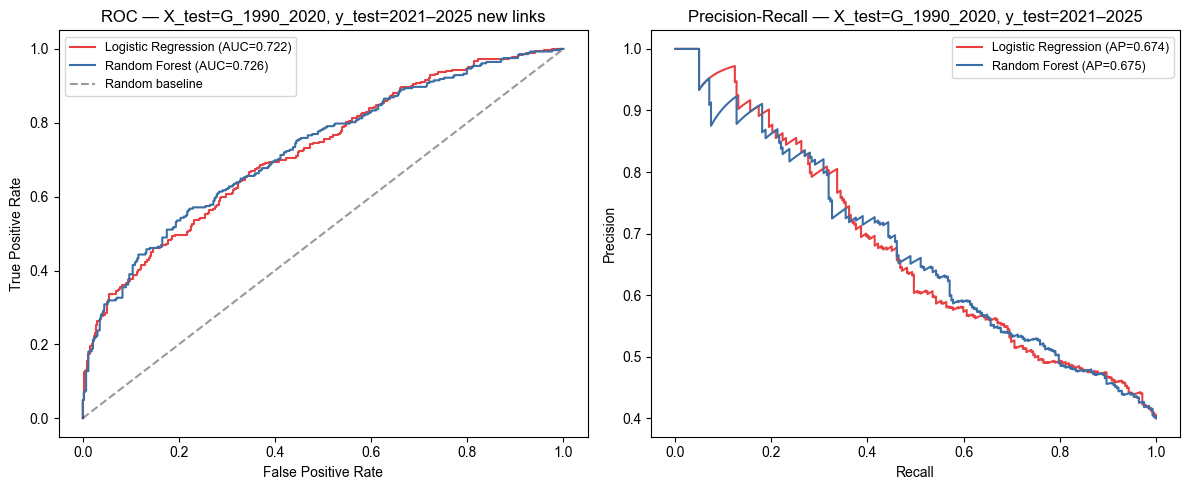

In [13]:
if not HAS_TEST:
    print('ROC/PR curves skipped: no test data.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for name, model, scaler, color in [
        ('Logistic Regression', lr_model, lr_scaler, '#e84040'),
        ('Random Forest',       rf_model, None,      '#3b6ea5'),
    ]:
        met         = lp_mod.evaluate_model(model, X_test, y_test, scaler=scaler)
        fpr, tpr, _ = lp_mod.roc_curve_data(model, X_test, y_test, scaler=scaler)
        pr,  rec, _ = lp_mod.pr_curve_data(model, X_test, y_test, scaler=scaler)
        axes[0].plot(fpr, tpr, color=color, label=f'{name} (AUC={met["auc_roc"]:.3f})')
        axes[1].plot(rec, pr,  color=color, label=f'{name} (AP={met["avg_precision"]:.3f})')

    axes[0].plot([0,1],[0,1],'k--',alpha=0.4, label='Random baseline')
    axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC — X_test=G_1990_2020, y_test=2021–2025 new links')
    axes[0].legend(fontsize=9)

    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall — X_test=G_1990_2020, y_test=2021–2025')
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig('../figures/link_pred_test_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


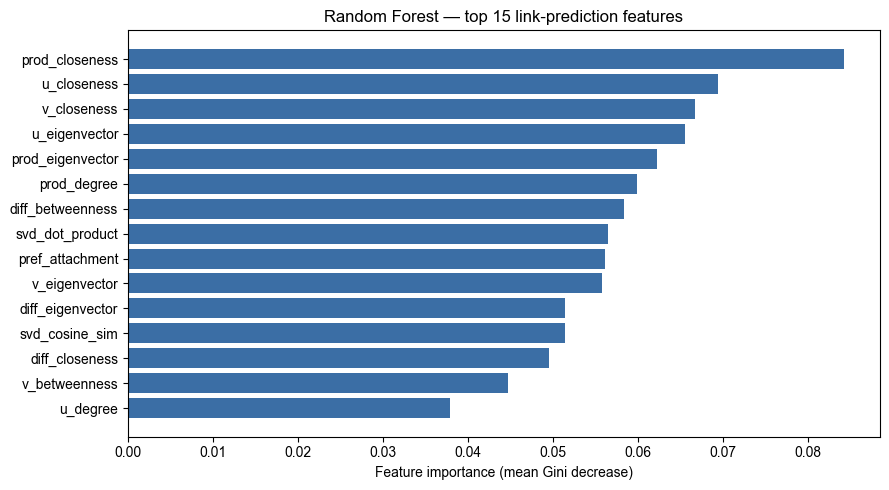

Top 5 features:
  prod_closeness                      0.0842
  u_closeness                         0.0694
  v_closeness                         0.0666
  u_eigenvector                       0.0656
  prod_eigenvector                    0.0622


In [14]:
# Random Forest feature importance (top 15)
# Uses feat_names_train (N2V-free, 23 features) — the features the model was trained on
fi_df = (pd.DataFrame({'feature': feat_names_train,
                        'importance': rf_model.feature_importances_})
           .sort_values('importance', ascending=False)
           .head(15))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1], color='#3b6ea5')
ax.set_xlabel('Feature importance (mean Gini decrease)')
ax.set_title('Random Forest — top 15 link-prediction features')
plt.tight_layout()
plt.savefig('../figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features:')
for _, row in fi_df.head(5).iterrows():
    print(f'  {row["feature"]:<35} {row["importance"]:.4f}')


## 6. Error analysis

**False positives (FP)**: the model predicted a collaboration that did NOT
materialise.  Sorted by predicted score descending — these are the model's
most confident wrong guesses.

**False negatives (FN)**: a collaboration DID form, but the model assigned
it a low score (missed it).  Sorted by predicted score ascending — these
are the most confidently-missed links.

Both error types are informative: FPs reveal what the model considers
"structurally likely" even when other factors blocked the collaboration;
FNs reveal collaborations driven by factors the model cannot see (e.g.
director choice, genre shift, personal relationships).

In [15]:
if not HAS_TEST:
    print('Error analysis skipped: no test data.')
else:
    fp_df, fn_df = lp_mod.error_analysis(
        best_model, X_test, y_test, all_test_pairs, G_1990_2020,
        n_examples=20, scaler=best_scaler)

    print('TOP FALSE POSITIVES')
    print('(Model predicted link 2021–2025 — it did NOT form)')
    print()
    print(fp_df.to_string(index=False))


TOP FALSE POSITIVES
(Model predicted link 2021–2025 — it did NOT form)

        u_name        v_name   y_prob  common_neighbors
  ליאור אשכנזי    עלי סלימאן 0.926088                 1
     הרצל טובי  מוני מושונוב 0.900489                 1
      טלי שרון      מנשה נוי 0.891036                 0
  אסף בן שמעון      נתן רביץ 0.828478                 1
     גילי שושן      עמוס תמם 0.825507                 0
  אלון אבוטבול    עידן ברקאי 0.785440                 0
      סלים דאו  עידית טפרסון 0.784312                 0
    דאנה איבגי    דליה שימקו 0.782858                 1
      אורי פפר  מורן רוזנבלט 0.780532                 1
אנה דוברוביצקי  מארק איווניר 0.772159                 1
    אורנה בנאי      דפנה דקל 0.769696                 1
      אווה חדד      אורי פפר 0.765297                 0
     מאיה מרון משה פולקנפליק 0.764814                 0
      דלית קהן      נדב גדג' 0.760241                 0
     חנה לסלאו      יוגב יפת 0.756838                 0
  ענבר סוירפמן   דניאל מורשת 0.7

In [16]:
if HAS_TEST:
    print('TOP FALSE NEGATIVES')
    print('(Link DID form 2021–2025 — model assigned a low score)')
    print()
    print(fn_df.to_string(index=False))
    print()
    print('Discussion:')
    print('  FP: actors with many common neighbours in G_1990_2020 — strong structural signal,')
    print('      but may be separated by genre or production circles.')
    print('  FN: collaborations driven by director choice or casting after 2020,')
    print('      invisible to the 1990-2020 topology.')


TOP FALSE NEGATIVES
(Link DID form 2021–2025 — model assigned a low score)

           u_name        v_name   y_prob  common_neighbors
         גיא לואל      עמית רהב 0.007834                 0
אלכסנדר סנדרוביץ'   מוטי בן ישי 0.031981                 0
       אלישע בנאי      תום אבני 0.096632                 0
        ניב סולטן      עמית רהב 0.101285                 0
         גיא לואל     ניב סולטן 0.124891                 0
         גיא לואל    נועם אימבר 0.125924                 0
         גיא לואל   שראל פיטרמן 0.128194                 0
    מעיין תורג'מן    קוסטה קפלן 0.155081                 0
       נועם אימבר      עמית רהב 0.160725                 0
       קוסטה קפלן      הדס ירון 0.161279                 0
      מאור שוויצר      עמית רהב 0.182227                 0
        ניב סולטן   שראל פיטרמן 0.184191                 0
         גיא עמיר      צחי הלוי 0.187749                 0
       עירית קפלן      עמית רהב 0.193979                 0
   דין מירושניקוב     הילה סעדה 0.19455

## 7. Future predictions (2026 and beyond)

The best model is applied to **G_1990_2025 (1990–2025)** to score every currently
unconnected pair of active actors.  Non-edges in G_1990_2025 are potential 2026+
collaborations.

The `years_ahead` parameter is used at inference time — change it to score
short-term (1 year) vs long-term (5 year) predictions with the **same model**.


In [17]:
FUTURE_YEARS_AHEAD = 5   # change to 1, 2, or 3 for shorter-horizon predictions

print(f'Scoring future collaborations with years_ahead={FUTURE_YEARS_AHEAD}...')
print('Computing features on G_1990_2025...')
cents_1990_2025   = lp_mod.compute_centralities(G_1990_2025)
svd_1990_2025 = lf.svd_node_embeddings(G_1990_2025, n_components=32, seed=SEED)

future_df = lp_mod.predict_future_collaborations(
    best_model, G_1990_2025, cents_1990_2025,
    svd_emb=svd_1990_2025,
    n2v_emb=None,
    years_ahead=FUTURE_YEARS_AHEAD,
    n_top=50, min_degree=2, max_candidates=15_000,
    seed=SEED, scaler=best_scaler)
print(f'Scored {len(future_df)} top candidates (years_ahead={FUTURE_YEARS_AHEAD}).')


Scoring future collaborations with years_ahead=5...
Computing features on G_1990_2025...
Scored 50 top candidates (years_ahead=5).


Top 30 predicted future collaborations:

                u_name             v_name     score  common_neighbors  u_degree  v_degree
0          אורי גבריאל          הרצל טובי  0.935809                 6        57        42
1          אברהם סלקטר       שלומי קוריאט  0.892034                 3        18        62
2          אברהם סלקטר          מוריס כהן  0.883714                 3        18        37
3            יגאל נאור            יפה לוי  0.879960                 2        40        46
4              אסי לוי        מוטי בן ישי  0.869312                 2        22        45
5             מנשה נוי       שלומי קוריאט  0.862471                 1        20        62
6              מלי לוי           עפר שכטר  0.860106                 2        17        46
7            הרצל טובי          ששון גבאי  0.859852                 3        42        39
8            אושרי כהן        מוטי בן ישי  0.858264                 2        30        45
9          אורי גבריאל        אלברט אילוז  0.852392        

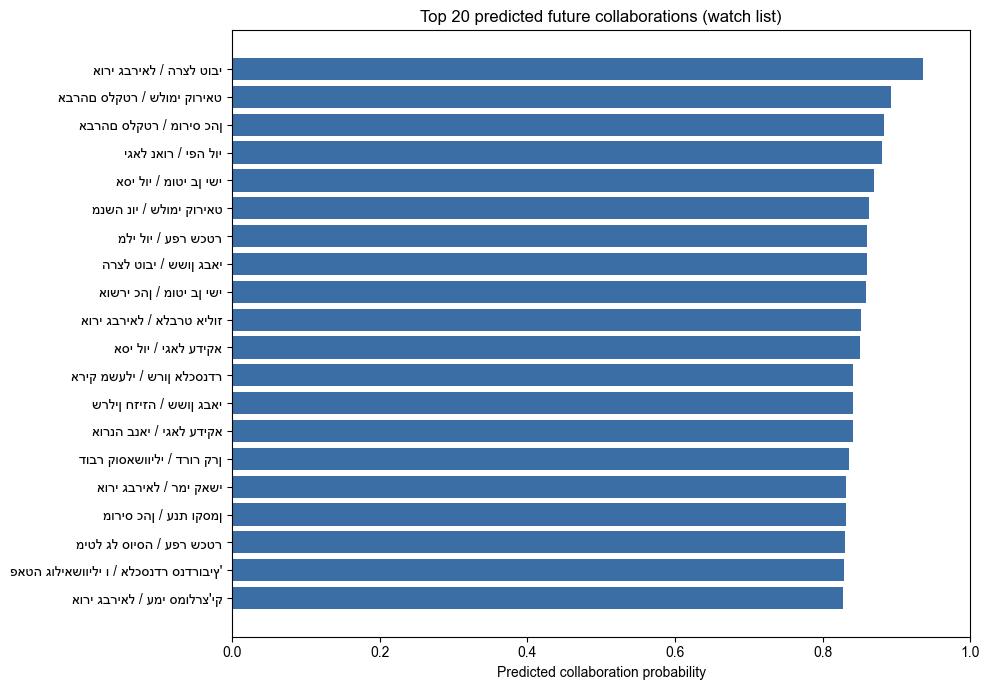

In [18]:
print('Top 30 predicted future collaborations:')
print()
top30 = future_df.head(30)[['u_name', 'v_name', 'score',
                              'common_neighbors', 'u_degree', 'v_degree']]
print(top30.to_string(index=True))

# Bar chart: top 20
top20 = future_df.head(20).copy()
top20['pair'] = top20['u_name'] + ' / ' + top20['v_name']

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20['pair'][::-1], top20['score'][::-1], color='#3b6ea5')
ax.set_xlabel('Predicted collaboration probability')
ax.set_title('Top 20 predicted future collaborations (watch list)')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig('../figures/future_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
import os
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

# Test metrics
pd.DataFrame([lr_metrics, rf_metrics],
             index=['Logistic Regression', 'Random Forest']).to_csv(
    '../data/processed/link_prediction_test_metrics.csv', encoding='utf-8-sig')
print('Saved link_prediction_test_metrics.csv')

# Error analysis
fp_df.to_csv('../data/processed/link_prediction_fp.csv',
              index=False, encoding='utf-8-sig')
fn_df.to_csv('../data/processed/link_prediction_fn.csv',
              index=False, encoding='utf-8-sig')
print('Saved link_prediction_fp.csv and link_prediction_fn.csv')

# Future predictions
future_df.to_csv('../data/processed/link_prediction_future.csv',
                  index=False, encoding='utf-8-sig')
print('Saved link_prediction_future.csv')
print()
print('All outputs saved to data/processed/ and figures/.')


Saved link_prediction_test_metrics.csv
Saved link_prediction_fp.csv and link_prediction_fn.csv
Saved link_prediction_future.csv

All outputs saved to data/processed/ and figures/.


## Summary

### Design
| | X (features) | y (labels) | years_ahead |
|---|---|---|---|
| **Train** | G_1990_2015: 1990–2015 | New links 2016–2020 | 5 |
| **Test**  | G_1990_2020:   1990–2020 | New links 2021–2025 | 5 |
| **Future** | G_1990_2025:  1990–2025 | — (2026+) | user-specified |

### Results (fill in from outputs above)
- **Best model**: ___
- **Test AUC-ROC**: LR = ___ | RF = ___
- **Test F1**: ___
- **Most important feature**: (see feature importance chart)

### Limitations
- Actors who debuted after 2015 cannot appear as training candidate pairs (cold-start).
- Test features (G_1990_2020, 1990–2020) have different distributions than training features
  (G_1990_2015, 1990–2015) — realistic but may reduce generalization.
- `years_ahead` is constant (5) for both train and test; to fully exploit it,
  train on multiple horizons (1-year, 3-year, 5-year examples).
- Negative sampling is random; degree-stratified sampling would reduce bias.
